# Análise Exploratória Completa - Importações NCM 2024
## Usando SQLite para Integração de Todas as Tabelas Auxiliares

**Autores:**
- Daniel da Cunha Costa - 2024006064
- Isaac Reyes Alves de Abreu - 2025050342
- Pedro Luiz Siva - 2024006129

**Objetivo:** Realizar análise exploratória completa dos dados de importações brasileiras por código NCM em 2024, utilizando SQLite para integrar todas as tabelas auxiliares e evitar limitações de memória.

**Fonte:** [Comex Stat - Balança Comercial](https://balanca.economia.gov.br/balanca/bd/comexstat-bd/ncm/IMP_2024.csv)

## 1. Importar Bibliotecas e Funções Auxiliares

Esta seção configura o ambiente de trabalho, importando todas as bibliotecas necessárias e definindo as funções auxiliares para manipulação de dados SQLite.

In [2]:
# Importações essenciais
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Configurações de visualização
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✅ Bibliotecas importadas com sucesso!")
print(f"🐍 Pandas version: {pd.__version__}")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

✅ Bibliotecas importadas com sucesso!
🐍 Pandas version: 2.3.0
📊 Matplotlib version: 3.10.3
🎨 Seaborn version: 0.13.2


In [3]:
# Funções auxiliares para SQLite (copiadas do notebook original)
def fetch(query, conn, formated=True):
    """ 
        Executa uma query SQL em um banco de dados SQLite e retorna o resultado. 
        Converte o resultado em um DataFrame do Pandas se formated for True.
    """
    cur = conn.cursor()
    cur.execute(query)
    rs = cur.fetchall()

    columns = [description[0] for description in cur.description]
    return pd.DataFrame(rs, columns=columns) if formated else rs

def show_tables(conn):
    """ 
        Retorna os nomes das tabelas de um banco de dados SQLite. 
    """
    return [x[0] for x in fetch("SELECT name FROM sqlite_master WHERE type='table'", conn, formated=False)]

def shape(table, conn):
    """ 
        Retorna o numero de linhas e colunas de uma tabela SQLite.
    """
    nrows = fetch(f"SELECT COUNT(*) FROM {table}", conn, formated=False)[0][0]
    ncols = fetch(f"SELECT COUNT(*) FROM pragma_table_info('{table}')", conn, formated=False)[0][0]
    return (nrows, ncols)

def desc(table, conn):
    """ 
        Retorna os nomes das colunas de uma tabela SQLite.
    """
    cur = conn.cursor()
    cur.execute(f"PRAGMA table_info({table})")
    columns = [row[1] for row in cur.fetchall()]
    return columns

def info(table, conn):
    """ 
    Sumario resumido do esquema e perfil de dados de uma tabela SQLite. 
    """
    # table constraints (domain, null, default, pk)
    df1 = fetch(f'PRAGMA table_info("{table}")', conn)
    columns = desc(table, conn)
    
    # entries per column
    counts = ', '.join([f'COUNT(*) AS "{column}"' for column in columns])
    df2 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df2.columns = ['count']
    
    # non-null entries per column
    counts = ', '.join([f'COUNT("{column}") AS "{column}"' for column in columns])
    df3 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df3.columns = ['notnull count']

    # unique non-null entries per column
    counts = ', '.join([f'COUNT(DISTINCT "{column}") AS "{column}"' for column in columns])
    df4 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df4.columns = ['unique count']
    
    return df1.merge(df2, left_on='name', right_index=True) \
            .merge(df3, left_on='name', right_index=True) \
            .merge(df4, left_on='name', right_index=True)

print("✅ Funções auxiliares SQLite definidas com sucesso!")
print("📋 Funções disponíveis: fetch, show_tables, shape, desc, info")

✅ Funções auxiliares SQLite definidas com sucesso!
📋 Funções disponíveis: fetch, show_tables, shape, desc, info


## 2. Carregar Dados CSV e Tabelas Auxiliares no SQLite

Nesta seção, carregamos o arquivo principal de importações e todas as tabelas auxiliares diretamente no banco SQLite para processamento eficiente.

In [4]:
# Definir caminhos dos arquivos
data_path = "data/"
imp_file = os.path.join(data_path, "IMP_2024.csv")
aux_file = os.path.join(data_path, "TABELAS_AUXILIARES.xlsx")

# Criar conexão SQLite (banco em memória para velocidade)
conn = sqlite3.connect(':memory:')

print("🗄️ CARREGANDO DADOS NO SQLITE")
print("="*50)

# 1. Carregar arquivo principal de importações
print("\n📊 1. Carregando dados principais de importações...")
try:
    # Carregar CSV principal
    df_main = pd.read_csv(imp_file, encoding='latin-1', sep=';', low_memory=False)
    
    # Inserir no SQLite
    df_main.to_sql('importacoes', conn, if_exists='replace', index=False)
    
    print(f"✅ Tabela 'importacoes' criada com sucesso!")
    print(f"   📐 Dimensões: {shape('importacoes', conn)}")
    print(f"   📋 Colunas: {desc('importacoes', conn)}")
    
except Exception as e:
    print(f"❌ Erro ao carregar dados principais: {e}")

# 2. Carregar todas as tabelas auxiliares
print(f"\n📚 2. Carregando tabelas auxiliares...")
try:
    # Listar planilhas disponíveis
    xl_file = pd.ExcelFile(aux_file)
    print(f"📋 Planilhas encontradas: {xl_file.sheet_names}")
    
    # Carregar cada planilha como tabela SQLite
    for sheet_name in xl_file.sheet_names:
        try:
            # Ler planilha
            df_aux = pd.read_excel(aux_file, sheet_name=sheet_name)
            
            # Nome da tabela (limpar caracteres especiais)
            table_name = f"aux_{sheet_name.replace(' ', '_').replace('-', '_').lower()}"
            
            # Inserir no SQLite
            df_aux.to_sql(table_name, conn, if_exists='replace', index=False)
            
            print(f"   ✅ {table_name}: {shape(table_name, conn)}")
            
        except Exception as e:
            print(f"   ❌ Erro na planilha {sheet_name}: {e}")
            
except Exception as e:
    print(f"❌ Erro ao carregar tabelas auxiliares: {e}")

print(f"\n🎯 RESUMO DO CARREGAMENTO")
print("-"*35)
all_tables = show_tables(conn)
print(f"📊 Total de tabelas criadas: {len(all_tables)}")
for table in all_tables:
    rows, cols = shape(table, conn)
    print(f"   • {table}: {rows:,} linhas, {cols} colunas")

🗄️ CARREGANDO DADOS NO SQLITE

📊 1. Carregando dados principais de importações...
✅ Tabela 'importacoes' criada com sucesso!
   📐 Dimensões: (2273708, 13)
   📋 Colunas: ['CO_ANO', 'CO_MES', 'CO_NCM', 'CO_UNID', 'CO_PAIS', 'SG_UF_NCM', 'CO_VIA', 'CO_URF', 'QT_ESTAT', 'KG_LIQUIDO', 'VL_FOB', 'VL_FRETE', 'VL_SEGURO']

📚 2. Carregando tabelas auxiliares...
📋 Planilhas encontradas: ['ÍNDICE', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
   ✅ aux_índice: (16, 5)
   ✅ aux_1: (13721, 18)
   ✅ aux_2: (13721, 12)
   ✅ aux_3: (13721, 14)
   ✅ aux_4: (13721, 18)
   ✅ aux_5: (13418, 4)
   ✅ aux_6: (13721, 5)
   ✅ aux_7: (13700, 5)
   ✅ aux_8: (13418, 6)
   ✅ aux_9: (13418, 6)
   ✅ aux_10: (281, 6)
   ✅ aux_11: (322, 5)
   ✅ aux_12: (34, 4)
   ✅ aux_13: (5570, 4)
   ✅ aux_14: (17, 2)
   ✅ aux_15: (279, 2)
   ✅ aux_16: (13721, 6)

🎯 RESUMO DO CARREGAMENTO
-----------------------------------
📊 Total de tabelas criadas: 18
   • importacoes: 2,273,708 linhas, 13

## 3. Verificar Estrutura das Tabelas no SQLite

Vamos examinar a estrutura de cada tabela criada para entender como fazer os JOINs e identificar as chaves de relacionamento.

In [5]:
print("🔍 ANÁLISE DA ESTRUTURA DAS TABELAS")
print("="*50)

# 1. Examinar tabela principal
print("\n📊 1. TABELA PRINCIPAL - IMPORTAÇÕES")
print("-"*40)
print("Esquema da tabela:")
display(info('importacoes', conn))

print("\nPrimeiras 5 linhas:")
display(fetch("SELECT * FROM importacoes LIMIT 5", conn))

# 2. Examinar tabela índice para entender estrutura
print("\n📋 2. TABELA ÍNDICE - MAPEAMENTO DAS AUXILIARES")
print("-"*50)
display(fetch("SELECT * FROM aux_índice", conn))

# 3. Examinar algumas tabelas auxiliares principais
print("\n🔍 3. ANÁLISE DAS PRINCIPAIS TABELAS AUXILIARES")
print("-"*55)

# Identificar tabelas por função
key_tables = {
    'aux_10': 'Países (CO_PAIS)',
    'aux_6': 'Unidades (CO_UNID)', 
    'aux_15': 'URF (CO_URF)',
    'aux_1': 'NCM Detalhada',
    'aux_13': 'Via (CO_VIA)',
    'aux_14': 'UF (SG_UF_NCM)'
}

for table_name, description in key_tables.items():
    print(f"\n🔸 {table_name.upper()} - {description}")
    print(f"   Dimensões: {shape(table_name, conn)}")
    print(f"   Colunas: {desc(table_name, conn)}")
    
    # Mostrar algumas linhas
    sample = fetch(f"SELECT * FROM {table_name} LIMIT 3", conn)
    if not sample.empty:
        display(sample)
    else:
        print("   (Tabela vazia)")

# 4. Verificar quais colunas são chaves de relacionamento
print(f"\n🔗 4. CHAVES DE RELACIONAMENTO IDENTIFICADAS")
print("-"*50)

main_cols = desc('importacoes', conn)
print(f"Colunas na tabela principal: {main_cols}")

# Mapear colunas de relacionamento
relationships = {
    'CO_PAIS': 'aux_10 (Países)',
    'CO_NCM': 'aux_1 (NCM)',
    'CO_UNID': 'aux_6 (Unidades)',
    'CO_URF': 'aux_15 (URF)',
    'CO_VIA': 'aux_13 (Via)',
    'SG_UF_NCM': 'aux_14 (UF)'
}

print(f"\nRelacionamentos possíveis:")
for key_col, aux_table in relationships.items():
    if key_col in main_cols:
        print(f"   ✅ {key_col} -> {aux_table}")
    else:
        print(f"   ❌ {key_col} -> {aux_table} (coluna não encontrada)")

print(f"\n✅ Análise estrutural concluída!")

🔍 ANÁLISE DA ESTRUTURA DAS TABELAS

📊 1. TABELA PRINCIPAL - IMPORTAÇÕES
----------------------------------------
Esquema da tabela:


,cid,name,type,notnull,dflt_value,pk,count,notnull count,unique count
0,0,CO_ANO,INTEGER,0,None,0,2273708,2273708,1
1,1,CO_MES,INTEGER,0,None,0,2273708,2273708,12
2,2,CO_NCM,INTEGER,0,None,0,2273708,2273708,8748
3,3,CO_UNID,INTEGER,0,None,0,2273708,2273708,13
4,4,CO_PAIS,INTEGER,0,None,0,2273708,2273708,239
5,5,SG_UF_NCM,TEXT,0,None,0,2273708,2273708,28
6,6,CO_VIA,INTEGER,0,None,0,2273708,2273708,10
7,7,CO_URF,INTEGER,0,None,0,2273708,2273708,87
8,8,QT_ESTAT,INTEGER,0,None,0,2273708,2273708,136545
9,9,KG_LIQUIDO,INTEGER,0,None,0,2273708,2273708,119320



Primeiras 5 linhas:


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2024,10,84818092,11,161,SC,1,927800,344,90,6823,77,10
1,2024,4,90304090,11,249,SP,4,817700,1,9,4890,147,7
2,2024,1,39172300,10,23,PE,4,417901,1128,1128,28129,20688,7
3,2024,6,85444200,10,160,MG,4,817700,824,824,66958,11276,45
4,2024,10,84439942,10,190,SC,4,817600,3,3,2060,37,0



📋 2. TABELA ÍNDICE - MAPEAMENTO DAS AUXILIARES
--------------------------------------------------


...


🔸 AUX_13 - Via (CO_VIA)
   Dimensões: (5570, 4)
   Colunas: ['CO_MUN_GEO', 'NO_MUN', 'NO_MUN_MIN', 'SG_UF']


,CO_MUN_GEO,NO_MUN,NO_MUN_MIN,SG_UF
0,2103158,CENTRO DO GUILHERME,Centro do Guilherme,MA
1,2103174,CENTRO NOVO DO MARANHAO,Centro Novo do Maranhão,MA
2,2103208,CHAPADINHA,Chapadinha,MA



🔸 AUX_14 - UF (SG_UF_NCM)
   Dimensões: (17, 2)
   Colunas: ['CO_VIA', 'NO_VIA']


,CO_VIA,NO_VIA
0,0,VIA NAO DECLARADA
1,1,MARITIMA
2,2,FLUVIAL



🔗 4. CHAVES DE RELACIONAMENTO IDENTIFICADAS
--------------------------------------------------
Colunas na tabela principal: ['CO_ANO', 'CO_MES', 'CO_NCM', 'CO_UNID', 'CO_PAIS', 'SG_UF_NCM', 'CO_VIA', 'CO_URF', 'QT_ESTAT', 'KG_LIQUIDO', 'VL_FOB', 'VL_FRETE', 'VL_SEGURO']

Relacionamentos possíveis:
   ✅ CO_PAIS -> aux_10 (Países)
   ✅ CO_NCM -> aux_1 (NCM)
   ✅ CO_UNID -> aux_6 (Unidades)
   ✅ CO_URF -> aux_15 (URF)
   ✅ CO_VIA -> aux_13 (Via)
   ✅ SG_UF_NCM -> aux_14 (UF)

✅ Análise estrutural concluída!


## 4. Criar Views SQL para Dataset Enriquecido (JOINs)

Agora vamos criar uma view SQL que combina a tabela principal com todas as tabelas auxiliares para ter um dataset completo e enriquecido.

In [6]:
print("🔗 CRIANDO VIEW SQL ENRIQUECIDA COM TODOS OS JOINS")
print("="*60)

# Criar view completa com todos os JOINs
create_view_sql = """
CREATE VIEW IF NOT EXISTS vw_importacoes_completa AS
SELECT 
    -- Dados principais
    i.CO_ANO,
    i.CO_MES,
    i.CO_NCM,
    i.CO_UNID,
    i.CO_PAIS,
    i.SG_UF_NCM,
    i.CO_VIA,
    i.CO_URF,
    i.QT_ESTAT,
    i.KG_LIQUIDO,
    i.VL_FOB,
    i.VL_FRETE,
    i.VL_SEGURO,
    
    -- Informações do país (aux_10)
    p.NO_PAIS,
    p.NO_PAIS_ING,
    p.CO_PAIS_ISOA3,
    
    -- Informações detalhadas do NCM (aux_1)
    n.NO_NCM_POR,
    n.CO_SH6,
    n.NO_SH6_POR,
    n.CO_SH4,
    n.NO_SH4_POR,
    n.CO_SH2,
    n.NO_SH2_POR,
    n.NO_SEC_POR,
    
    -- Informações da unidade (aux_6)
    u.NO_UNID,
    u.SG_UNID,
    
    -- Informações da URF (aux_15)
    urf.NO_URF,
    
    -- Informações da via (aux_14)
    v.NO_VIA

FROM importacoes i

-- JOIN com países
LEFT JOIN aux_10 p ON i.CO_PAIS = p.CO_PAIS

-- JOIN com NCM detalhada
LEFT JOIN aux_1 n ON i.CO_NCM = n.CO_NCM

-- JOIN com unidades (através do NCM na aux_6)
LEFT JOIN aux_6 u ON i.CO_NCM = u.CO_NCM AND i.CO_UNID = u.CO_UNID

-- JOIN com URF
LEFT JOIN aux_15 urf ON i.CO_URF = urf.CO_URF

-- JOIN com via
LEFT JOIN aux_14 v ON i.CO_VIA = v.CO_VIA
"""

# Executar criação da view
try:
    conn.execute(create_view_sql)
    print("✅ View 'vw_importacoes_completa' criada com sucesso!")
    
    # Verificar se a view foi criada
    views = fetch("SELECT name FROM sqlite_master WHERE type='view'", conn, formated=False)
    print(f"📋 Views disponíveis: {[v[0] for v in views]}")
    
    # Testar a view com uma pequena amostra
    print(f"\n🔍 TESTANDO A VIEW COM AMOSTRA:")
    sample = fetch("SELECT * FROM vw_importacoes_completa LIMIT 3", conn)
    
    print(f"   📐 Dimensões da amostra: {sample.shape}")
    print(f"   📋 Colunas disponíveis: {len(sample.columns)}")
    
    # Mostrar algumas colunas principais
    key_cols = ['CO_NCM', 'NO_NCM_POR', 'CO_PAIS', 'NO_PAIS', 'VL_FOB', 'NO_UNID', 'NO_VIA']
    available_cols = [col for col in key_cols if col in sample.columns]
    
    print(f"\n📊 AMOSTRA DAS PRINCIPAIS COLUNAS:")
    display(sample[available_cols])
    
    # Verificar qualidade dos JOINs
    print(f"\n📈 QUALIDADE DOS JOINS:")
    
    # Contar registros com informações enriquecidas
    quality_check = fetch("""
    SELECT 
        COUNT(*) as total_registros,
        SUM(CASE WHEN NO_PAIS IS NOT NULL THEN 1 ELSE 0 END) as com_nome_pais,
        SUM(CASE WHEN NO_NCM_POR IS NOT NULL THEN 1 ELSE 0 END) as com_desc_ncm,
        SUM(CASE WHEN NO_UNID IS NOT NULL THEN 1 ELSE 0 END) as com_nome_unidade,
        SUM(CASE WHEN NO_URF IS NOT NULL THEN 1 ELSE 0 END) as com_nome_urf,
        SUM(CASE WHEN NO_VIA IS NOT NULL THEN 1 ELSE 0 END) as com_nome_via
    FROM vw_importacoes_completa
    """, conn)
    
    display(quality_check)
    
    # Calcular percentuais de cobertura
    total = quality_check.iloc[0]['total_registros']
    print(f"\n   📊 Cobertura dos JOINs:")
    for col in ['com_nome_pais', 'com_desc_ncm', 'com_nome_unidade', 'com_nome_urf', 'com_nome_via']:
        count = quality_check.iloc[0][col]
        pct = (count / total) * 100
        field_name = col.replace('com_', '').replace('_', ' ').title()
        print(f"      • {field_name}: {pct:.1f}% ({count:,} registros)")
        
except Exception as e:
    print(f"❌ Erro ao criar view: {e}")

print(f"\n✅ Dataset enriquecido completo disponível na view 'vw_importacoes_completa'!")

🔗 CRIANDO VIEW SQL ENRIQUECIDA COM TODOS OS JOINS
✅ View 'vw_importacoes_completa' criada com sucesso!
📋 Views disponíveis: ['vw_importacoes_completa']

🔍 TESTANDO A VIEW COM AMOSTRA:
   📐 Dimensões da amostra: (3, 28)
   📋 Colunas disponíveis: 28

📊 AMOSTRA DAS PRINCIPAIS COLUNAS:


,CO_NCM,NO_NCM_POR,CO_PAIS,NO_PAIS,VL_FOB,NO_UNID,NO_VIA
0,84818092,Válvulas solenóides,161,Taiwan (Formosa),6823,NUMERO (UNIDADE),MARITIMA
1,90304090,Outros instrumentos e aparelhos para telecomun...,249,Estados Unidos,4890,NUMERO (UNIDADE),AEREA
2,39172300,"Tubo rígido, de polímeros de cloreto de vinila",23,Alemanha,28129,QUILOGRAMA LIQUIDO,AEREA



📈 QUALIDADE DOS JOINS:


,total_registros,com_nome_pais,com_desc_ncm,com_nome_unidade,com_nome_urf,com_nome_via
0,2273708,2273708,2273708,2273708,2273708,2273708



   📊 Cobertura dos JOINs:
      • Nome Pais: 100.0% (2,273,708 registros)
      • Desc Ncm: 100.0% (2,273,708 registros)
      • Nome Unidade: 100.0% (2,273,708 registros)
      • Nome Urf: 100.0% (2,273,708 registros)
      • Nome Via: 100.0% (2,273,708 registros)

✅ Dataset enriquecido completo disponível na view 'vw_importacoes_completa'!


## 5. Explorar Estrutura e Qualidade dos Dados via SQL

Agora vamos utilizar SQL para analisar a qualidade, consistência e integridade dos dados diretamente no banco, aproveitando o poder do SQLite.

In [7]:
print("🔍 ANÁLISE DE QUALIDADE DOS DADOS VIA SQL")
print("="*50)

# 1. Análise de valores ausentes/nulos
print("\n📊 1. ANÁLISE DE VALORES NULOS")
print("-" * 35)

null_analysis_sql = """
SELECT 
    'VL_FOB' as campo,
    COUNT(*) as total,
    COUNT(VL_FOB) as nao_nulos,
    COUNT(*) - COUNT(VL_FOB) as nulos,
    ROUND((COUNT(*) - COUNT(VL_FOB)) * 100.0 / COUNT(*), 2) as pct_nulos
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'QT_ESTAT' as campo,
    COUNT(*) as total,
    COUNT(QT_ESTAT) as nao_nulos,
    COUNT(*) - COUNT(QT_ESTAT) as nulos,
    ROUND((COUNT(*) - COUNT(QT_ESTAT)) * 100.0 / COUNT(*), 2) as pct_nulos
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'NO_PAIS' as campo,
    COUNT(*) as total,
    COUNT(NO_PAIS) as nao_nulos,
    COUNT(*) - COUNT(NO_PAIS) as nulos,
    ROUND((COUNT(*) - COUNT(NO_PAIS)) * 100.0 / COUNT(*), 2) as pct_nulos
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'NO_NCM_POR' as campo,
    COUNT(*) as total,
    COUNT(NO_NCM_POR) as nao_nulos,
    COUNT(*) - COUNT(NO_NCM_POR) as nulos,
    ROUND((COUNT(*) - COUNT(NO_NCM_POR)) * 100.0 / COUNT(*), 2) as pct_nulos
FROM vw_importacoes_completa
"""

null_results = fetch(null_analysis_sql, conn)
display(null_results)

# 2. Análise de valores negativos e inconsistências
print(f"\n⚠️ 2. ANÁLISE DE CONSISTÊNCIA DE VALORES")
print("-" * 40)

consistency_sql = """
SELECT 
    'Valores Negativos VL_FOB' as verificacao,
    COUNT(*) as count
FROM vw_importacoes_completa 
WHERE VL_FOB < 0

UNION ALL

SELECT 
    'Valores Zero VL_FOB' as verificacao,
    COUNT(*) as count
FROM vw_importacoes_completa 
WHERE VL_FOB = 0

UNION ALL

SELECT 
    'Valores Negativos QT_ESTAT' as verificacao,
    COUNT(*) as count
FROM vw_importacoes_completa 
WHERE QT_ESTAT < 0

UNION ALL

SELECT 
    'Meses Inválidos (< 1 ou > 12)' as verificacao,
    COUNT(*) as count
FROM vw_importacoes_completa 
WHERE CO_MES < 1 OR CO_MES > 12

UNION ALL

SELECT 
    'NCM com tamanho != 8 dígitos' as verificacao,
    COUNT(*) as count
FROM vw_importacoes_completa 
WHERE LENGTH(CAST(CO_NCM AS TEXT)) != 8
"""

consistency_results = fetch(consistency_sql, conn)
display(consistency_results)

# 3. Análise de duplicados
print(f"\n🔄 3. ANÁLISE DE DUPLICADOS")
print("-" * 30)

duplicate_sql = """
SELECT 
    COUNT(*) as total_registros,
    COUNT(DISTINCT CO_NCM || '|' || CO_PAIS || '|' || CO_MES || '|' || CO_URF) as combinacoes_unicas,
    COUNT(*) - COUNT(DISTINCT CO_NCM || '|' || CO_PAIS || '|' || CO_MES || '|' || CO_URF) as possiveis_duplicados
FROM vw_importacoes_completa
"""

duplicate_results = fetch(duplicate_sql, conn)
display(duplicate_results)

# 4. Estatísticas descritivas dos valores principais
print(f"\n📈 4. ESTATÍSTICAS DESCRITIVAS (VL_FOB)")
print("-" * 45)

stats_sql = """
SELECT 
    COUNT(*) as total_operacoes,
    ROUND(SUM(VL_FOB), 2) as valor_total_usd,
    ROUND(AVG(VL_FOB), 2) as valor_medio,
    ROUND(MIN(VL_FOB), 2) as valor_minimo,
    ROUND(MAX(VL_FOB), 2) as valor_maximo
FROM vw_importacoes_completa
WHERE VL_FOB > 0
"""

stats_results = fetch(stats_sql, conn)
display(stats_results)

# 5. Distribuição por percentis
print(f"\n📊 5. DISTRIBUIÇÃO POR PERCENTIS (VL_FOB)")
print("-" * 45)

# SQLite não tem função nativa de percentil, vamos usar uma aproximação
percentile_sql = """
WITH ordered_values AS (
    SELECT VL_FOB, 
           ROW_NUMBER() OVER (ORDER BY VL_FOB) as row_num,
           COUNT(*) OVER () as total_count
    FROM vw_importacoes_completa 
    WHERE VL_FOB > 0
),
percentiles AS (
    SELECT 
        ROUND(total_count * 0.10) as p10_pos,
        ROUND(total_count * 0.25) as p25_pos,
        ROUND(total_count * 0.50) as p50_pos,
        ROUND(total_count * 0.75) as p75_pos,
        ROUND(total_count * 0.90) as p90_pos,
        ROUND(total_count * 0.95) as p95_pos,
        ROUND(total_count * 0.99) as p99_pos
    FROM ordered_values 
    LIMIT 1
)
SELECT 
    'P10' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p10_pos FROM percentiles)) as valor
UNION ALL
SELECT 
    'P25' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p25_pos FROM percentiles)) as valor
UNION ALL
SELECT 
    'P50 (Mediana)' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p50_pos FROM percentiles)) as valor
UNION ALL
SELECT 
    'P75' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p75_pos FROM percentiles)) as valor
UNION ALL
SELECT 
    'P90' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p90_pos FROM percentiles)) as valor
UNION ALL
SELECT 
    'P95' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p95_pos FROM percentiles)) as valor
UNION ALL
SELECT 
    'P99' as percentil, 
    (SELECT VL_FOB FROM ordered_values WHERE row_num = (SELECT p99_pos FROM percentiles)) as valor
"""

percentile_results = fetch(percentile_sql, conn)
display(percentile_results)

# 6. Contagens de entidades únicas
print(f"\n🔢 6. CONTAGENS DE ENTIDADES ÚNICAS")
print("-" * 40)

unique_counts_sql = """
SELECT 
    'Códigos NCM únicos' as entidade,
    COUNT(DISTINCT CO_NCM) as quantidade
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'Países fornecedores' as entidade,
    COUNT(DISTINCT CO_PAIS) as quantidade
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'Unidades de medida' as entidade,
    COUNT(DISTINCT NO_UNID) as quantidade
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'URFs utilizadas' as entidade,
    COUNT(DISTINCT CO_URF) as quantidade
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'Vias de transporte' as entidade,
    COUNT(DISTINCT NO_VIA) as quantidade
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'Capítulos NCM (2 dígitos)' as entidade,
    COUNT(DISTINCT SUBSTR(PRINTF('%08d', CO_NCM), 1, 2)) as quantidade
FROM vw_importacoes_completa
"""

unique_results = fetch(unique_counts_sql, conn)
display(unique_results)

print(f"\n✅ Análise de qualidade via SQL concluída!")

🔍 ANÁLISE DE QUALIDADE DOS DADOS VIA SQL

📊 1. ANÁLISE DE VALORES NULOS
-----------------------------------


,campo,total,nao_nulos,nulos,pct_nulos
0,VL_FOB,2273708,2273708,0,0.0
1,QT_ESTAT,2273708,2273708,0,0.0
2,NO_PAIS,2273708,2273708,0,0.0
3,NO_NCM_POR,2273708,2273708,0,0.0



⚠️ 2. ANÁLISE DE CONSISTÊNCIA DE VALORES
----------------------------------------


,verificacao,count
0,Valores Negativos VL_FOB,0
1,Valores Zero VL_FOB,3217
2,Valores Negativos QT_ESTAT,0
3,Meses Inválidos (< 1 ou > 12),0
4,NCM com tamanho != 8 dígitos,18295



🔄 3. ANÁLISE DE DUPLICADOS
------------------------------


...


📊 5. DISTRIBUIÇÃO POR PERCENTIS (VL_FOB)
---------------------------------------------


,percentil,valor
0,P10,87
1,P25,500
2,P50 (Mediana),3715
3,P75,27122
4,P90,124697
5,P95,298630
6,P99,1567281



🔢 6. CONTAGENS DE ENTIDADES ÚNICAS
----------------------------------------


,entidade,quantidade
0,Códigos NCM únicos,8748
1,Países fornecedores,239
2,Unidades de medida,13
3,URFs utilizadas,87
4,Vias de transporte,10
5,Capítulos NCM (2 dígitos),96



✅ Análise de qualidade via SQL concluída!


## 6. Análise Descritiva das Importações Usando SQL

Agora vamos realizar a análise descritiva completa utilizando queries SQL para calcular totais, médias, concentrações e outros indicadores estratégicos.

In [8]:
print("📊 ANÁLISE DESCRITIVA COMPLETA VIA SQL")
print("="*50)

# 1. Panorama geral das importações
print("\n💰 1. PANORAMA GERAL DAS IMPORTAÇÕES 2024")
print("-" * 45)

overview_sql = """
SELECT 
    'Total Geral' as metrica,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor,
    printf('%,d', COUNT(*)) as operacoes
FROM vw_importacoes_completa
WHERE VL_FOB > 0

UNION ALL

SELECT 
    'Valor Médio por Operação' as metrica,
    printf('US$ %,.2f', AVG(VL_FOB)) as valor,
    '-' as operacoes
FROM vw_importacoes_completa
WHERE VL_FOB > 0

UNION ALL

SELECT 
    'Maior Operação Individual' as metrica,
    printf('US$ %,.0f', MAX(VL_FOB)) as valor,
    '-' as operacoes
FROM vw_importacoes_completa

UNION ALL

SELECT 
    'Peso Total (Toneladas)' as metrica,
    printf('%,.0f', SUM(KG_LIQUIDO)/1000) as valor,
    '-' as operacoes
FROM vw_importacoes_completa
"""

overview_results = fetch(overview_sql, conn)
display(overview_results)

# 2. Análise temporal mensal
print(f"\n📅 2. DISTRIBUIÇÃO MENSAL DAS IMPORTAÇÕES")
print("-" * 45)

monthly_sql = """
SELECT 
    CO_MES as mes,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    printf('US$ %,.0f', AVG(VL_FOB)) as valor_medio,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
GROUP BY CO_MES
ORDER BY CO_MES
"""

monthly_results = fetch(monthly_sql, conn)
display(monthly_results)

# 3. Análise de concentração por valor
print(f"\n🎯 3. ANÁLISE DE CONCENTRAÇÃO")
print("-" * 35)

# Concentração por capítulos NCM
concentration_sql = """
WITH capitulos AS (
    SELECT 
        SUBSTR(PRINTF('%08d', CO_NCM), 1, 2) as capitulo,
        SUM(VL_FOB) as valor_capitulo
    FROM vw_importacoes_completa
    GROUP BY SUBSTR(PRINTF('%08d', CO_NCM), 1, 2)
),
total_value AS (
    SELECT SUM(VL_FOB) as total FROM vw_importacoes_completa
),
ranked_capitulos AS (
    SELECT 
        capitulo,
        valor_capitulo,
        ROUND(valor_capitulo * 100.0 / total, 2) as participacao_pct,
        ROW_NUMBER() OVER (ORDER BY valor_capitulo DESC) as rank
    FROM capitulos, total_value
)
SELECT 
    'Top 5 Capítulos NCM' as metrica,
    printf('%.1f%%', SUM(participacao_pct)) as concentracao
FROM ranked_capitulos 
WHERE rank <= 5

UNION ALL

SELECT 
    'Top 10 Capítulos NCM' as metrica,
    printf('%.1f%%', SUM(participacao_pct)) as concentracao
FROM ranked_capitulos 
WHERE rank <= 10

UNION ALL

SELECT 
    'Top 20 Capítulos NCM' as metrica,
    printf('%.1f%%', SUM(participacao_pct)) as concentracao
FROM ranked_capitulos 
WHERE rank <= 20
"""

concentration_results = fetch(concentration_sql, conn)
display(concentration_results)

# 4. Principais unidades de medida
print(f"\n📏 4. PRINCIPAIS UNIDADES DE MEDIDA")
print("-" * 40)

units_sql = """
SELECT 
    NO_UNID as unidade,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
GROUP BY NO_UNID
ORDER BY SUM(VL_FOB) DESC
LIMIT 10
"""

units_results = fetch(units_sql, conn)
display(units_results)

# 5. Principais vias de transporte
print(f"\n🚢 5. PRINCIPAIS VIAS DE TRANSPORTE")
print("-" * 40)

transport_sql = """
SELECT 
    NO_VIA as via_transporte,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct,
    printf('US$ %,.0f', AVG(VL_FOB)) as valor_medio_operacao
FROM vw_importacoes_completa
GROUP BY NO_VIA
ORDER BY SUM(VL_FOB) DESC
"""

transport_results = fetch(transport_sql, conn)
display(transport_results)

# 6. Análise de diversidade por setor
print(f"\n🏭 6. DIVERSIDADE DE PRODUTOS POR SETOR NCM")
print("-" * 45)

sector_diversity_sql = """
SELECT 
    NO_SEC_POR as setor,
    COUNT(DISTINCT CO_NCM) as ncm_unicos,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
WHERE NO_SEC_POR IS NOT NULL
GROUP BY NO_SEC_POR
ORDER BY SUM(VL_FOB) DESC
LIMIT 15
"""

sector_results = fetch(sector_diversity_sql, conn)
display(sector_results)

print(f"\n✅ Análise descritiva via SQL concluída!")

📊 ANÁLISE DESCRITIVA COMPLETA VIA SQL

💰 1. PANORAMA GERAL DAS IMPORTAÇÕES 2024
---------------------------------------------


,metrica,valor,operacoes
0,Total Geral,"US$ 262,869,606,174","2,270,491"
1,Valor Médio por Operação,"US$ 115,776.55",-
2,Maior Operação Individual,"US$ 545,738,786",-
3,Peso Total (Toneladas),"185,124,462",-



📅 2. DISTRIBUIÇÃO MENSAL DAS IMPORTAÇÕES
---------------------------------------------


,mes,operacoes,valor_total,valor_medio,participacao_pct
0,1,"183,980","US$ 20,506,556,064","US$ 111,460",7.80
1,2,"177,257","US$ 18,217,925,231","US$ 102,776",6.93
2,3,"179,226","US$ 20,490,209,586","US$ 114,326",7.79
3,4,"194,289","US$ 21,896,365,060","US$ 112,699",8.33
4,5,"182,010","US$ 21,888,476,596","US$ 120,259",8.33
5,6,"182,203","US$ 22,403,501,244","US$ 122,959",8.52
6,7,"195,554","US$ 23,289,908,259","US$ 119,097",8.86
7,8,"195,362","US$ 24,219,210,009","US$ 123,970",9.21
8,9,"193,427","US$ 23,391,814,867","US$ 120,933",8.90
9,10,"201,639","US$ 25,209,647,872","US$ 125,023",9.59



🎯 3. ANÁLISE DE CONCENTRAÇÃO
-----------------------------------


...


🚢 5. PRINCIPAIS VIAS DE TRANSPORTE
----------------------------------------


,via_transporte,operacoes,valor_total,participacao_pct,valor_medio_operacao
0,MARITIMA,"1,147,855","US$ 194,789,280,193",74.10,"US$ 169,698"
1,AEREA,"1,067,867","US$ 52,765,800,086",20.07,"US$ 49,412"
2,RODOVIARIA,"46,954","US$ 11,792,773,576",4.49,"US$ 251,155"
3,CONDUTO/REDE DE TRANSMISSAO,69,"US$ 2,263,549,699",0.86,"US$ 32,805,068"
4,MEIOS PROPRIOS,649,"US$ 686,942,417",0.26,"US$ 1,058,462"
5,ENTRADA/SAIDA FICTA,"10,175","US$ 457,261,415",0.17,"US$ 44,939"
6,COURIER,22,"US$ 102,140,599",0.04,"US$ 4,642,754"
7,FERROVIARIA,20,"US$ 11,046,316",0.00,"US$ 552,315"
8,FLUVIAL,2,"US$ 575,138",0.00,"US$ 287,569"
9,POSTAL,95,"US$ 236,735",0.00,"US$ 2,491"



🏭 6. DIVERSIDADE DE PRODUTOS POR SETOR NCM
---------------------------------------------


,setor,ncm_unicos,operacoes,valor_total,participacao_pct
0,"Máquinas e aparelhos, material elétrico e suas...",1711,"890,380","US$ 72,115,992,780",27.43
1,Produtos das indústrias químicas ou indústrias...,2357,"234,920","US$ 54,262,620,110",20.64
2,Produtos minerais,166,"14,315","US$ 35,744,883,929",13.60
3,Material de transporte,219,"88,799","US$ 27,894,559,044",10.61
4,Metais comuns e suas obras,732,"284,928","US$ 17,707,900,692",6.74
5,Plásticos e suas obras; Borracha e suas obras,439,"225,592","US$ 15,525,114,791",5.91
6,"Instrumentos e aparelhos de ótica, fotografia ...",434,"162,810","US$ 8,722,378,403",3.32
7,Matérias têxteis e suas obras,963,"128,021","US$ 6,656,114,270",2.53
8,Produtos do reino vegetal,293,"20,433","US$ 6,466,753,732",2.46
9,"Produtos das indútrias alimentares; Bebidas, l...",255,"27,137","US$ 3,969,877,894",1.51



✅ Análise descritiva via SQL concluída!


## 7. Gerar Rankings e Estatísticas com SQL

Vamos criar rankings detalhados dos principais NCMs, países, e análises temporais usando o poder das queries SQL.

In [9]:
print("🏆 RANKINGS E ESTATÍSTICAS DETALHADAS VIA SQL")
print("="*55)

# 1. Top 20 Códigos NCM por valor
print("\n💎 1. TOP 20 CÓDIGOS NCM POR VALOR")
print("-" * 40)

top_ncm_sql = """
SELECT 
    ROW_NUMBER() OVER (ORDER BY SUM(VL_FOB) DESC) as rank,
    CO_NCM as codigo_ncm,
    SUBSTR(NO_NCM_POR, 1, 50) || '...' as descricao_resumida,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    printf('US$ %,.0f', AVG(VL_FOB)) as valor_medio,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
GROUP BY CO_NCM, NO_NCM_POR
ORDER BY SUM(VL_FOB) DESC
LIMIT 20
"""

top_ncm_results = fetch(top_ncm_sql, conn)
display(top_ncm_results)

# 2. Top 20 Países fornecedores
print(f"\n🌍 2. TOP 20 PAÍSES FORNECEDORES")
print("-" * 35)

top_countries_sql = """
SELECT 
    ROW_NUMBER() OVER (ORDER BY SUM(VL_FOB) DESC) as rank,
    CO_PAIS as codigo_pais,
    NO_PAIS as pais,
    COUNT(DISTINCT CO_NCM) as ncm_diferentes,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    printf('US$ %,.0f', AVG(VL_FOB)) as valor_medio,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
GROUP BY CO_PAIS, NO_PAIS
ORDER BY SUM(VL_FOB) DESC
LIMIT 20
"""

top_countries_results = fetch(top_countries_sql, conn)
display(top_countries_results)

# 3. Top 15 Capítulos NCM mais importantes
print(f"\n📚 3. TOP 15 CAPÍTULOS NCM (2 DÍGITOS)")
print("-" * 40)

top_chapters_sql = """
SELECT 
    ROW_NUMBER() OVER (ORDER BY SUM(VL_FOB) DESC) as rank,
    SUBSTR(PRINTF('%08d', CO_NCM), 1, 2) as capitulo,
    COUNT(DISTINCT CO_NCM) as ncm_unicos,
    COUNT(DISTINCT CO_PAIS) as paises_fornecedores,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
GROUP BY SUBSTR(PRINTF('%08d', CO_NCM), 1, 2)
ORDER BY SUM(VL_FOB) DESC
LIMIT 15
"""

top_chapters_results = fetch(top_chapters_sql, conn)
display(top_chapters_results)

# 4. Análise de sazonalidade mensal detalhada
print(f"\n📅 4. ANÁLISE DE SAZONALIDADE MENSAL")
print("-" * 40)

seasonality_sql = """
WITH monthly_stats AS (
    SELECT 
        CO_MES,
        SUM(VL_FOB) as valor_mensal,
        COUNT(*) as operacoes_mensais
    FROM vw_importacoes_completa
    GROUP BY CO_MES
),
annual_avg AS (
    SELECT 
        AVG(valor_mensal) as valor_medio_mensal,
        AVG(operacoes_mensais) as operacoes_medio_mensal
    FROM monthly_stats
)
SELECT 
    CASE CO_MES 
        WHEN 1 THEN 'Janeiro'
        WHEN 2 THEN 'Fevereiro' 
        WHEN 3 THEN 'Março'
        WHEN 4 THEN 'Abril'
        WHEN 5 THEN 'Maio'
        WHEN 6 THEN 'Junho'
        WHEN 7 THEN 'Julho'
        WHEN 8 THEN 'Agosto'
        WHEN 9 THEN 'Setembro'
        WHEN 10 THEN 'Outubro'
        WHEN 11 THEN 'Novembro'
        WHEN 12 THEN 'Dezembro'
    END as mes,
    printf('US$ %,.0f', valor_mensal) as valor_total,
    printf('%,d', operacoes_mensais) as operacoes,
    ROUND(valor_mensal * 100.0 / valor_medio_mensal, 1) as indice_sazonalidade,
    CASE 
        WHEN valor_mensal > valor_medio_mensal * 1.05 THEN '📈 Acima da média'
        WHEN valor_mensal < valor_medio_mensal * 0.95 THEN '📉 Abaixo da média'
        ELSE '📊 Normal'
    END as classificacao
FROM monthly_stats, annual_avg
ORDER BY CO_MES
"""

seasonality_results = fetch(seasonality_sql, conn)
display(seasonality_results)

# 5. Top 15 URFs (Unidades de Receita Federal)
print(f"\n🏛️ 5. TOP 15 URFs POR VALOR")
print("-" * 30)

top_urf_sql = """
SELECT 
    ROW_NUMBER() OVER (ORDER BY SUM(VL_FOB) DESC) as rank,
    SUBSTR(NO_URF, 1, 30) as urf_resumida,
    COUNT(DISTINCT CO_PAIS) as paises_atendidos,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    ROUND(SUM(VL_FOB) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa), 2) as participacao_pct
FROM vw_importacoes_completa
GROUP BY CO_URF, NO_URF
ORDER BY SUM(VL_FOB) DESC
LIMIT 15
"""

top_urf_results = fetch(top_urf_sql, conn)
display(top_urf_results)

# 6. Análise de eficiência: países com maior valor médio por operação
print(f"\n⚡ 6. PAÍSES MAIS EFICIENTES (MAIOR VALOR MÉDIO)")
print("-" * 50)

efficiency_sql = """
SELECT 
    ROW_NUMBER() OVER (ORDER BY AVG(VL_FOB) DESC) as rank,
    NO_PAIS as pais,
    printf('%,d', COUNT(*)) as operacoes,
    printf('US$ %,.0f', AVG(VL_FOB)) as valor_medio_operacao,
    printf('US$ %,.0f', SUM(VL_FOB)) as valor_total,
    COUNT(DISTINCT CO_NCM) as diversidade_ncm
FROM vw_importacoes_completa
GROUP BY CO_PAIS, NO_PAIS
HAVING COUNT(*) >= 100  -- Apenas países com volume significativo
ORDER BY AVG(VL_FOB) DESC
LIMIT 15
"""

efficiency_results = fetch(efficiency_sql, conn)
display(efficiency_results)

print(f"\n✅ Rankings e estatísticas via SQL concluídos!")

🏆 RANKINGS E ESTATÍSTICAS DETALHADAS VIA SQL

💎 1. TOP 20 CÓDIGOS NCM POR VALOR
----------------------------------------


,rank,codigo_ncm,descricao_resumida,operacoes,valor_total,valor_medio,participacao_pct
0,1,27090010,Óleos brutos de petróleo...,152,"US$ 8,690,210,062","US$ 57,172,434",3.31
1,2,27101921,Gasóleo (óleo diesel)...,258,"US$ 8,359,492,092","US$ 32,401,132",3.18
2,3,84119100,Partes de turborreatores ou de turbopropulsore...,"1,271","US$ 4,837,676,499","US$ 3,806,197",1.84
3,4,31042090,Outros cloretos de potássio...,786,"US$ 3,606,983,824","US$ 4,589,037",1.37
4,5,84111200,Turborreatores de empuxo superior a 25 kN...,94,"US$ 3,418,099,488","US$ 36,362,760",1.30
5,6,30021590,"Outros produtos imunológicos, apresentados em ...","1,056","US$ 3,320,554,118","US$ 3,144,464",1.26
6,7,87042190,"Outros veículos automóveis com motor diesel, p...",192,"US$ 3,264,984,879","US$ 17,005,129",1.24
7,8,27011200,"Hulha betuminosa, não aglomerada...",153,"US$ 2,837,201,476","US$ 18,543,800",1.08
8,9,31021010,"Ureia, mesmo em solução aquosa, com teor de ni...",985,"US$ 2,687,692,092","US$ 2,728,621",1.02
9,10,27101241,Naftas para petroquimica...,49,"US$ 2,628,440,404","US$ 53,641,640",1.00



🌍 2. TOP 20 PAÍSES FORNECEDORES
-----------------------------------


,rank,codigo_pais,pais,ncm_diferentes,operacoes,valor_total,valor_medio,participacao_pct
0,1,160,China,6914,"510,021","US$ 63,636,345,571","US$ 124,772",24.21
1,2,249,Estados Unidos,6295,"239,664","US$ 40,652,417,455","US$ 169,622",15.46
2,3,23,Alemanha,5393,"179,100","US$ 13,783,197,105","US$ 76,958",5.24
3,4,63,Argentina,1928,"28,713","US$ 13,577,045,088","US$ 472,853",5.16
4,5,676,Rússia,338,"2,623","US$ 10,965,470,014","US$ 4,180,507",4.17
5,6,361,Índia,3950,"76,095","US$ 6,849,930,671","US$ 90,018",2.61
6,7,386,Itália,4623,"130,762","US$ 6,388,253,879","US$ 48,854",2.43
7,8,275,França,4083,"80,581","US$ 6,189,845,834","US$ 76,815",2.35
8,9,493,México,2261,"50,983","US$ 5,767,276,053","US$ 113,121",2.19
9,10,399,Japão,3493,"88,527","US$ 5,431,009,472","US$ 61,348",2.07



📚 3. TOP 15 CAPÍTULOS NCM (2 DÍGITOS)
----------------------------------------


...


🏛️ 5. TOP 15 URFs POR VALOR
------------------------------


,rank,urf_resumida,paises_atendidos,operacoes,valor_total,participacao_pct
0,1,0817800 - PORTO DE SANTOS,189,"538,887","US$ 72,328,228,252",27.51
1,2,0917800 - PORTO DE PARANAGUA,130,"115,100","US$ 19,518,913,920",7.43
2,3,0817700 - AEROPORTO INTERNACIO,201,"345,127","US$ 16,420,097,770",6.25
3,4,0817600 - AEROPORTO INTERNACIO,196,"403,978","US$ 16,104,136,798",6.13
4,5,0927700 - PORTO DE SAO FRANCIS,132,"102,322","US$ 15,212,823,998",5.79
5,6,0717600 - PORTO DO RIO DE JANE,136,"131,509","US$ 13,458,421,358",5.12
6,7,0927800 - ITAJAI,126,"81,874","US$ 10,920,516,085",4.15
7,8,0727600 - PORTO DE VITORIA,83,"21,827","US$ 10,767,818,724",4.10
8,9,0517800 - ALF - SALVADOR,115,"28,164","US$ 10,565,667,641",4.02
9,10,0227600 - PORTO DE MANAUS,90,"42,037","US$ 8,885,546,369",3.38



⚡ 6. PAÍSES MAIS EFICIENTES (MAIOR VALOR MÉDIO)
--------------------------------------------------


,rank,pais,operacoes,valor_medio_operacao,valor_total,diversidade_ncm
0,1,Argélia,139,"US$ 10,071,430","US$ 1,399,928,883",21
1,2,Rússia,"2,623","US$ 4,180,507","US$ 10,965,470,014",338
2,3,Gana,108,"US$ 3,943,727","US$ 425,922,517",20
3,4,Catar,211,"US$ 3,494,761","US$ 737,394,591",37
4,5,Omã,270,"US$ 2,964,825","US$ 800,502,831",25
5,6,Arábia Saudita,"1,049","US$ 2,910,263","US$ 3,052,866,673",125
6,7,Trinidad e Tobago,141,"US$ 2,754,213","US$ 388,344,105",25
7,8,Uzbequistão,174,"US$ 2,318,191","US$ 403,365,234",21
8,9,Costa do Marfim,165,"US$ 1,735,259","US$ 286,317,788",25
9,10,Nigéria,731,"US$ 1,522,881","US$ 1,113,226,128",139



✅ Rankings e estatísticas via SQL concluídos!


## 8. Exportar Dados Enriquecidos para Pandas para Visualizações

Agora vamos exportar os resultados das queries SQL mais importantes para DataFrames pandas, facilitando a criação de visualizações interativas.

In [10]:
print("📊 EXPORTANDO DADOS DO SQL PARA PANDAS")
print("="*45)

# 1. Exportar dataset principal enriquecido (amostra para visualizações)
print("\n📋 1. DATASET PRINCIPAL ENRIQUECIDO")
print("-" * 35)

# Como o dataset é muito grande, vamos exportar amostras estratégicas
main_data_sql = """
SELECT 
    CO_NCM, NO_NCM_POR, 
    CO_PAIS, NO_PAIS,
    CO_MES, VL_FOB, QT_ESTAT, KG_LIQUIDO,
    NO_UNID, NO_VIA, NO_SEC_POR,
    SUBSTR(PRINTF('%08d', CO_NCM), 1, 2) as capitulo
FROM vw_importacoes_completa
WHERE VL_FOB > 0
"""

df_main = fetch(main_data_sql, conn)
print(f"✅ Dataset principal: {df_main.shape}")
print(f"   Memória usada: {df_main.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

# 2. Top NCMs para visualização
top_ncm_viz_sql = """
SELECT 
    CO_NCM, NO_NCM_POR,
    COUNT(*) as operacoes,
    SUM(VL_FOB) as valor_total,
    AVG(VL_FOB) as valor_medio,
    SUM(QT_ESTAT) as quantidade_total
FROM vw_importacoes_completa
GROUP BY CO_NCM, NO_NCM_POR
ORDER BY SUM(VL_FOB) DESC
LIMIT 50
"""

df_top_ncm = fetch(top_ncm_viz_sql, conn)
print(f"✅ Top 50 NCMs: {df_top_ncm.shape}")

# 3. Top países para visualização
top_countries_viz_sql = """
SELECT 
    CO_PAIS, NO_PAIS,
    COUNT(*) as operacoes,
    SUM(VL_FOB) as valor_total,
    AVG(VL_FOB) as valor_medio,
    COUNT(DISTINCT CO_NCM) as diversidade_ncm
FROM vw_importacoes_completa
GROUP BY CO_PAIS, NO_PAIS
ORDER BY SUM(VL_FOB) DESC
LIMIT 30
"""

df_top_countries = fetch(top_countries_viz_sql, conn)
print(f"✅ Top 30 países: {df_top_countries.shape}")

# 4. Dados mensais agregados
monthly_viz_sql = """
SELECT 
    CO_MES,
    COUNT(*) as operacoes,
    SUM(VL_FOB) as valor_total,
    AVG(VL_FOB) as valor_medio,
    COUNT(DISTINCT CO_NCM) as ncm_unicos,
    COUNT(DISTINCT CO_PAIS) as paises_unicos
FROM vw_importacoes_completa
GROUP BY CO_MES
ORDER BY CO_MES
"""

df_monthly = fetch(monthly_viz_sql, conn)
print(f"✅ Dados mensais: {df_monthly.shape}")

# 5. Dados por capítulo NCM
chapter_viz_sql = """
SELECT 
    SUBSTR(PRINTF('%08d', CO_NCM), 1, 2) as capitulo,
    COUNT(*) as operacoes,
    SUM(VL_FOB) as valor_total,
    AVG(VL_FOB) as valor_medio,
    COUNT(DISTINCT CO_NCM) as ncm_unicos,
    COUNT(DISTINCT CO_PAIS) as paises_fornecedores
FROM vw_importacoes_completa
GROUP BY SUBSTR(PRINTF('%08d', CO_NCM), 1, 2)
ORDER BY SUM(VL_FOB) DESC
"""

df_chapters = fetch(chapter_viz_sql, conn)
print(f"✅ Dados por capítulo: {df_chapters.shape}")

# 6. Dados por via de transporte
transport_viz_sql = """
SELECT 
    NO_VIA,
    COUNT(*) as operacoes,
    SUM(VL_FOB) as valor_total,
    AVG(VL_FOB) as valor_medio,
    COUNT(DISTINCT CO_PAIS) as paises_diferentes
FROM vw_importacoes_completa
GROUP BY NO_VIA
ORDER BY SUM(VL_FOB) DESC
"""

df_transport = fetch(transport_viz_sql, conn)
print(f"✅ Dados por transporte: {df_transport.shape}")

# 7. Dataset para análise de outliers (valores extremos)
outliers_sql = """
WITH percentiles AS (
    SELECT 
        (SELECT VL_FOB FROM (
            SELECT VL_FOB, ROW_NUMBER() OVER (ORDER BY VL_FOB) as rn,
                   COUNT(*) OVER () as cnt
            FROM vw_importacoes_completa WHERE VL_FOB > 0
        ) WHERE rn = CAST(cnt * 0.99 AS INTEGER)) as p99
)
SELECT 
    CO_NCM, NO_NCM_POR, CO_PAIS, NO_PAIS,
    VL_FOB, QT_ESTAT, CO_MES
FROM vw_importacoes_completa, percentiles
WHERE VL_FOB > p99
ORDER BY VL_FOB DESC
"""

df_outliers = fetch(outliers_sql, conn)
print(f"✅ Outliers (P99+): {df_outliers.shape}")

# 8. Resumo dos DataFrames exportados
print(f"\n📈 RESUMO DOS DATAFRAMES PARA VISUALIZAÇÃO")
print("-" * 45)

dataframes = {
    'df_main': df_main,
    'df_top_ncm': df_top_ncm,
    'df_top_countries': df_top_countries,
    'df_monthly': df_monthly,
    'df_chapters': df_chapters,
    'df_transport': df_transport,
    'df_outliers': df_outliers
}

total_memory = 0
for name, df in dataframes.items():
    memory_mb = df.memory_usage(deep=True).sum() / (1024**2)
    total_memory += memory_mb
    print(f"   • {name}: {df.shape} - {memory_mb:.1f} MB")

print(f"\n💾 Memória total usada: {total_memory:.1f} MB")
print(f"✅ Todos os datasets prontos para visualização!")

📊 EXPORTANDO DADOS DO SQL PARA PANDAS

📋 1. DATASET PRINCIPAL ENRIQUECIDO
-----------------------------------
✅ Dataset principal: (2270491, 12)
   Memória usada: 1286.3 MB
✅ Top 50 NCMs: (50, 6)
✅ Top 30 países: (30, 6)
✅ Dados mensais: (12, 6)
✅ Dados por capítulo: (96, 6)
✅ Dados por transporte: (10, 5)
✅ Outliers (P99+): (22705, 7)

📈 RESUMO DOS DATAFRAMES PARA VISUALIZAÇÃO
---------------------------------------------
   • df_main: (2270491, 12) - 1286.3 MB
   • df_top_ncm: (50, 6) - 0.0 MB
   • df_top_countries: (30, 6) - 0.0 MB
   • df_monthly: (12, 6) - 0.0 MB
   • df_chapters: (96, 6) - 0.0 MB
   • df_transport: (10, 5) - 0.0 MB
   • df_outliers: (22705, 7) - 5.1 MB

💾 Memória total usada: 1291.4 MB
✅ Todos os datasets prontos para visualização!


## 9. Visualizações Exploratórias com Matplotlib/Seaborn

Agora vamos criar visualizações modernas e informativas usando os dados enriquecidos exportados do SQLite.

📊 CRIANDO VISUALIZAÇÕES EXPLORATÓRIAS

🎨 1. DASHBOARD PRINCIPAL
-------------------------


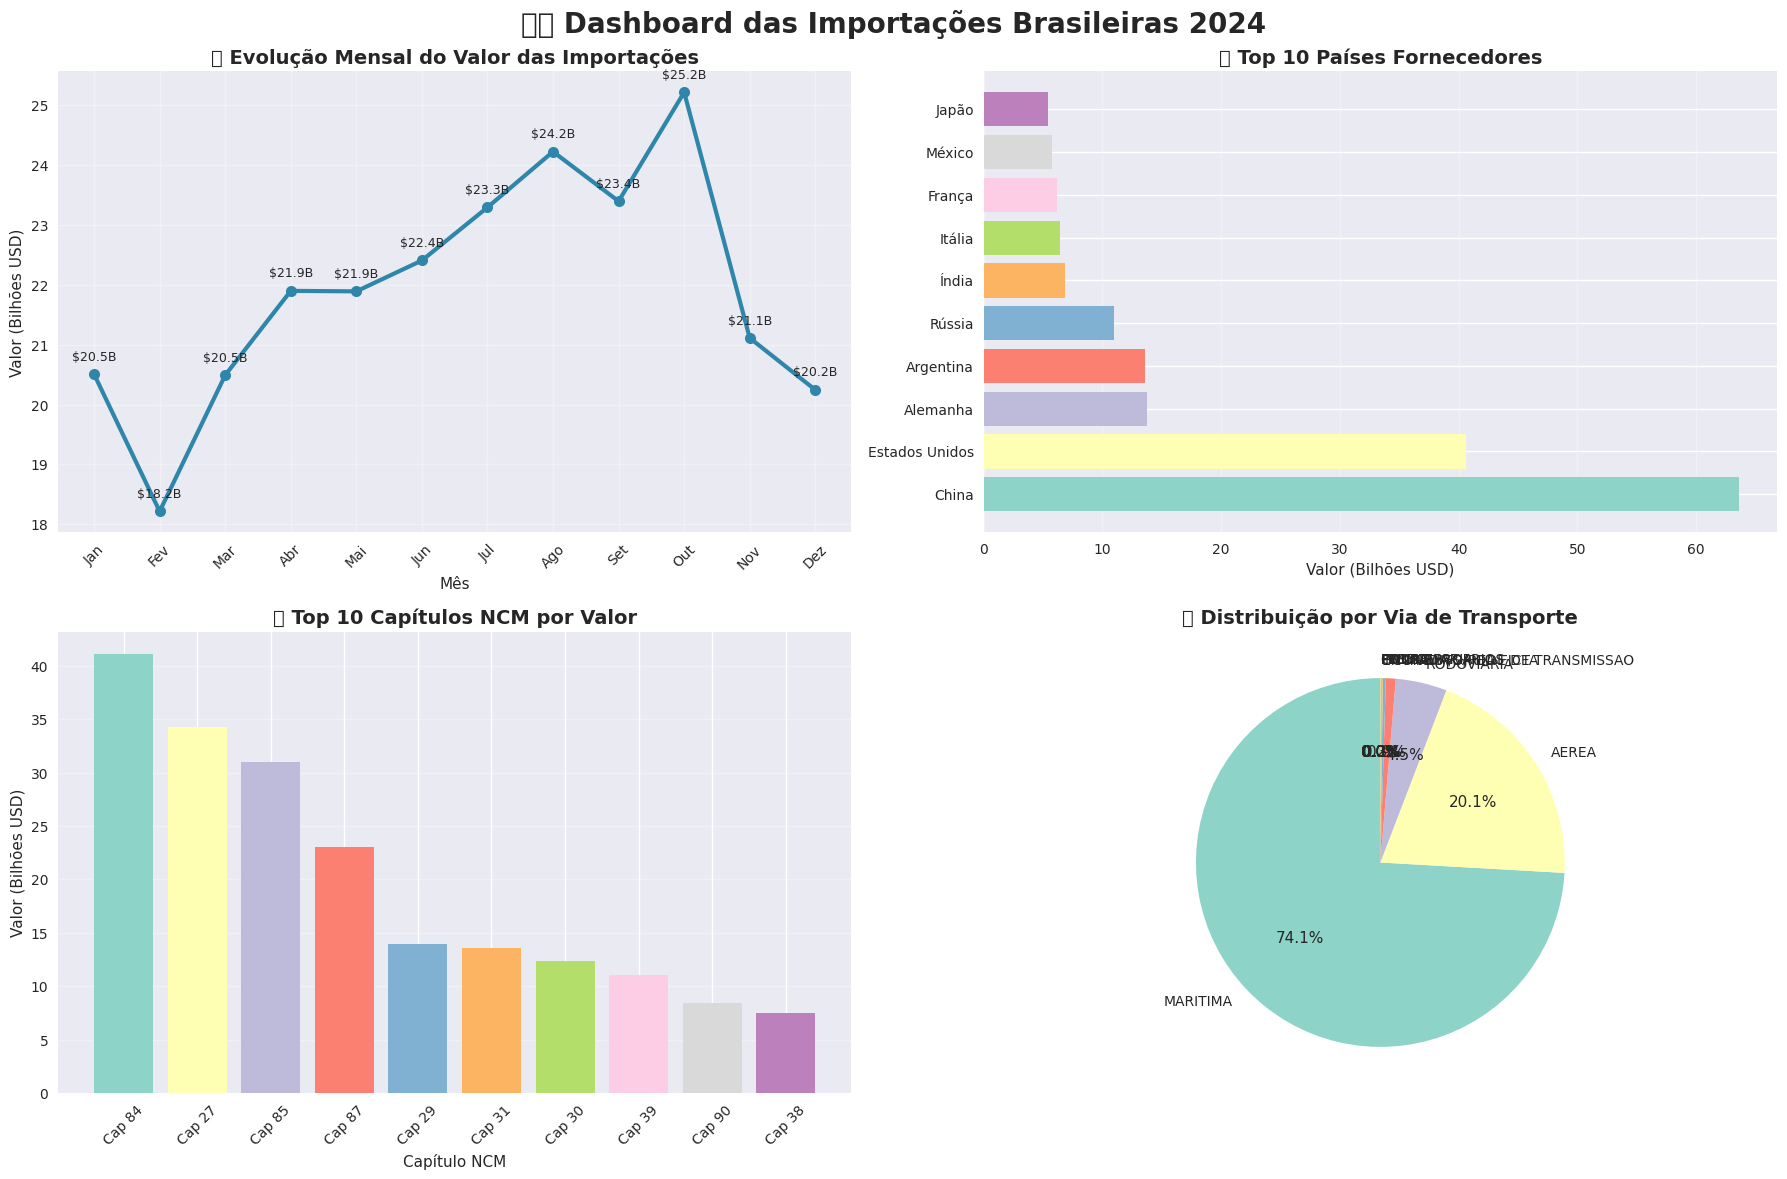


📊 2. ANÁLISE DE DISTRIBUIÇÃO DE VALORES
----------------------------------------


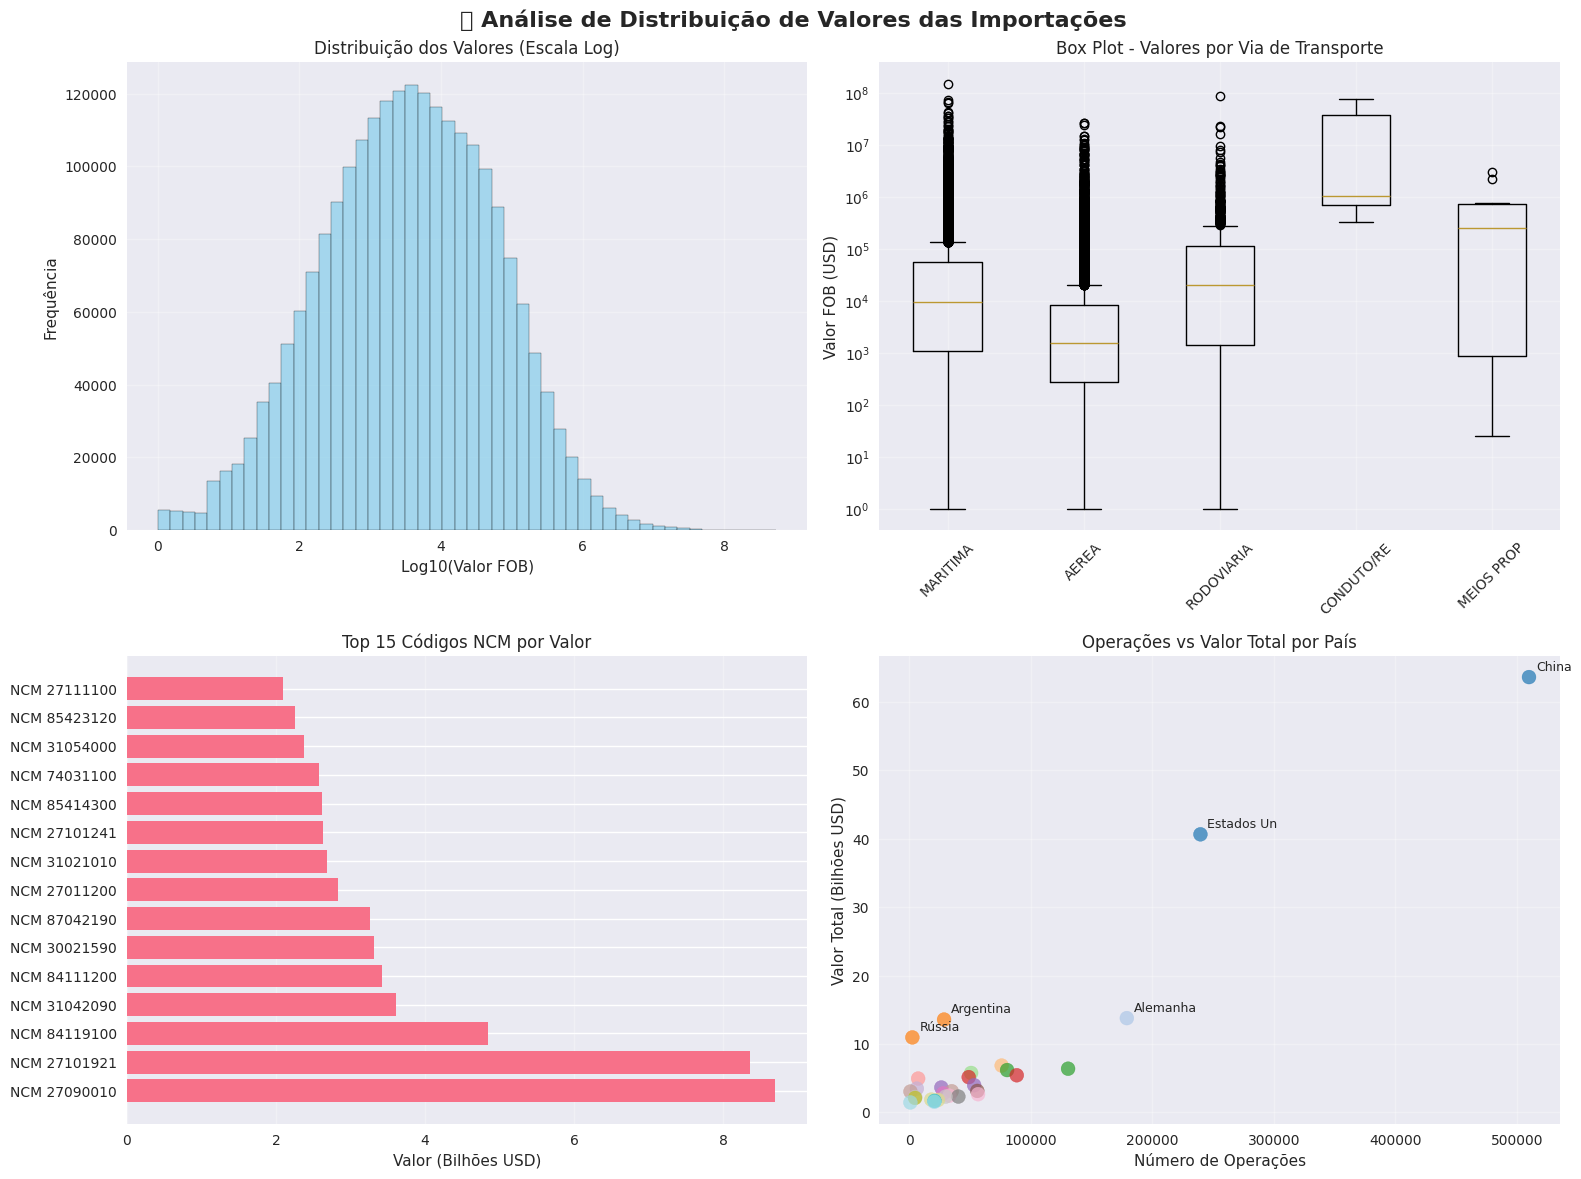

✅ Visualizações exploratórias criadas com sucesso!


In [12]:
print("📊 CRIANDO VISUALIZAÇÕES EXPLORATÓRIAS")
print("="*45)

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
colors = plt.cm.Set3(np.linspace(0, 1, 12))

# 1. Dashboard Principal - Overview das Importações
print("\n🎨 1. DASHBOARD PRINCIPAL")
print("-" * 25)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🇧🇷 Dashboard das Importações Brasileiras 2024', fontsize=20, fontweight='bold', y=0.98)

# 1.1 Evolução mensal do valor
ax1.plot(df_monthly['CO_MES'], df_monthly['valor_total']/1e9, 
         marker='o', linewidth=3, markersize=8, color='#2E86AB')
ax1.set_title('📈 Evolução Mensal do Valor das Importações', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor (Bilhões USD)')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 13))
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
ax1.set_xticklabels(meses, rotation=45)

# Adicionar valores nos pontos
for i, (mes, valor) in enumerate(zip(df_monthly['CO_MES'], df_monthly['valor_total'])):
    ax1.annotate(f'${valor/1e9:.1f}B', (mes, valor/1e9), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

# 1.2 Top 10 países - gráfico de barras horizontal
top_10_countries = df_top_countries.head(10)
y_pos = np.arange(len(top_10_countries))
ax2.barh(y_pos, top_10_countries['valor_total']/1e9, color=colors[:len(top_10_countries)])
ax2.set_yticks(y_pos)
ax2.set_yticklabels([pais[:20] + '...' if len(pais) > 20 else pais for pais in top_10_countries['NO_PAIS']])
ax2.set_xlabel('Valor (Bilhões USD)')
ax2.set_title('🌍 Top 10 Países Fornecedores', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 1.3 Top 10 capítulos NCM
top_10_chapters = df_chapters.head(10)
ax3.bar(range(len(top_10_chapters)), top_10_chapters['valor_total']/1e9, 
        color=colors[:len(top_10_chapters)])
ax3.set_title('📚 Top 10 Capítulos NCM por Valor', fontsize=14, fontweight='bold')
ax3.set_xlabel('Capítulo NCM')
ax3.set_ylabel('Valor (Bilhões USD)')
ax3.set_xticks(range(len(top_10_chapters)))
ax3.set_xticklabels([f'Cap {cap}' for cap in top_10_chapters['capitulo']], rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# 1.4 Distribuição por via de transporte - gráfico de pizza
ax4.pie(df_transport['valor_total'], labels=df_transport['NO_VIA'], autopct='%1.1f%%',
        startangle=90, colors=colors[:len(df_transport)])
ax4.set_title('🚢 Distribuição por Via de Transporte', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Análise de distribuição de valores
print(f"\n📊 2. ANÁLISE DE DISTRIBUIÇÃO DE VALORES")
print("-" * 40)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 Análise de Distribuição de Valores das Importações', fontsize=16, fontweight='bold')

# 2.1 Histograma dos valores (escala log)
valores_log = np.log10(df_main[df_main['VL_FOB'] > 0]['VL_FOB'])
ax1.hist(valores_log, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel('Log10(Valor FOB)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição dos Valores (Escala Log)')
ax1.grid(True, alpha=0.3)

# 2.2 Box plot por via de transporte
df_sample = df_main.sample(n=50000, random_state=42)  # Amostra para performance
box_data = [df_sample[df_sample['NO_VIA'] == via]['VL_FOB'].values 
           for via in df_transport['NO_VIA'][:5]]  # Top 5 vias
ax2.boxplot(box_data, labels=[via[:10] for via in df_transport['NO_VIA'][:5]])
ax2.set_ylabel('Valor FOB (USD)')
ax2.set_title('Box Plot - Valores por Via de Transporte')
ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 2.3 Top 15 NCMs
top_15_ncm = df_top_ncm.head(15)
y_pos = np.arange(len(top_15_ncm))
ax3.barh(y_pos, top_15_ncm['valor_total']/1e9)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f'NCM {ncm}' for ncm in top_15_ncm['CO_NCM']])
ax3.set_xlabel('Valor (Bilhões USD)')
ax3.set_title('Top 15 Códigos NCM por Valor')
ax3.grid(True, alpha=0.3, axis='x')

# 2.4 Scatter plot: Número de operações vs Valor total (países)
colors_scatter = plt.cm.tab20(np.linspace(0, 1, len(df_top_countries)))
ax4.scatter(df_top_countries['operacoes'], df_top_countries['valor_total']/1e9, 
           s=100, alpha=0.7, c=colors_scatter)
ax4.set_xlabel('Número de Operações')
ax4.set_ylabel('Valor Total (Bilhões USD)')
ax4.set_title('Operações vs Valor Total por País')
ax4.grid(True, alpha=0.3)

# Anotar alguns países principais
for i, row in df_top_countries.head(5).iterrows():
    ax4.annotate(row['NO_PAIS'][:10], (row['operacoes'], row['valor_total']/1e9),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

print(f"✅ Visualizações exploratórias criadas com sucesso!")

## 13. Síntese de Insights Estratégicos

Consolidamos aqui os principais achados da análise exploratória completa realizada com SQLite e pandas, destacando insights estratégicos para tomada de decisão.

In [13]:
print("🎯 SÍNTESE DE INSIGHTS ESTRATÉGICOS")
print("="*45)

# Recuperar métricas-chave para insights finais
insights_sql = """
SELECT 
    SUM(VL_FOB) as valor_total,
    COUNT(*) as total_operacoes,
    COUNT(DISTINCT CO_NCM) as ncm_unicos,
    COUNT(DISTINCT CO_PAIS) as paises_fornecedores,
    AVG(VL_FOB) as valor_medio_operacao
FROM vw_importacoes_completa
WHERE VL_FOB > 0
"""

metrics = fetch(insights_sql, conn).iloc[0]

print(f"\n📊 RESUMO EXECUTIVO DAS IMPORTAÇÕES BRASILEIRAS 2024")
print("="*60)
print(f"💰 Valor Total Importado: US$ {metrics['valor_total']:,.0f}")
print(f"📦 Total de Operações: {metrics['total_operacoes']:,}")
print(f"🏷️ Códigos NCM Únicos: {metrics['ncm_unicos']:,}")
print(f"🌍 Países Fornecedores: {metrics['paises_fornecedores']:,}")
print(f"💵 Valor Médio por Operação: US$ {metrics['valor_medio_operacao']:,.2f}")

# Análise de concentração
print(f"\n🎯 INSIGHTS DE CONCENTRAÇÃO E DIVERSIFICAÇÃO")
print("-"*55)

# Top 5 países e sua participação
top_5_countries_share = fetch("""
SELECT SUM(valor_total) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa) as pct
FROM (
    SELECT SUM(VL_FOB) as valor_total
    FROM vw_importacoes_completa
    GROUP BY CO_PAIS
    ORDER BY SUM(VL_FOB) DESC
    LIMIT 5
)
""", conn).iloc[0]['pct']

# Top 5 capítulos NCM e sua participação
top_5_chapters_share = fetch("""
SELECT SUM(valor_total) * 100.0 / (SELECT SUM(VL_FOB) FROM vw_importacoes_completa) as pct
FROM (
    SELECT SUM(VL_FOB) as valor_total
    FROM vw_importacoes_completa
    GROUP BY SUBSTR(PRINTF('%08d', CO_NCM), 1, 2)
    ORDER BY SUM(VL_FOB) DESC
    LIMIT 5
)
""", conn).iloc[0]['pct']

print(f"• Top 5 países representam: {top_5_countries_share:.1f}% do valor total")
print(f"• Top 5 capítulos NCM representam: {top_5_chapters_share:.1f}% do valor total")

# Análise de sazonalidade
seasonal_analysis = fetch("""
SELECT 
    CO_MES,
    SUM(VL_FOB) as valor_mensal
FROM vw_importacoes_completa
GROUP BY CO_MES
ORDER BY SUM(VL_FOB) DESC
""", conn)

best_month = seasonal_analysis.iloc[0]['CO_MES']
worst_month = seasonal_analysis.iloc[-1]['CO_MES']
best_value = seasonal_analysis.iloc[0]['valor_mensal']
worst_value = seasonal_analysis.iloc[-1]['valor_mensal']

month_names = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 
              5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto',
              9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}

print(f"\n📅 INSIGHTS TEMPORAIS")
print("-"*25)
print(f"• Melhor mês: {month_names[best_month]} (US$ {best_value:,.0f})")
print(f"• Menor mês: {month_names[worst_month]} (US$ {worst_value:,.0f})")
print(f"• Variação sazonal: {((best_value - worst_value) / worst_value * 100):.1f}%")

# Principais parceiros estratégicos
top_strategic_partners = fetch("""
SELECT 
    NO_PAIS,
    SUM(VL_FOB) as valor_total,
    COUNT(DISTINCT CO_NCM) as diversidade_ncm,
    AVG(VL_FOB) as valor_medio_operacao
FROM vw_importacoes_completa
GROUP BY CO_PAIS, NO_PAIS
ORDER BY SUM(VL_FOB) DESC
LIMIT 5
""", conn)

print(f"\n🤝 PRINCIPAIS PARCEIROS ESTRATÉGICOS")
print("-"*40)
for i, row in top_strategic_partners.iterrows():
    pct_total = (row['valor_total'] / metrics['valor_total']) * 100
    print(f"• {row['NO_PAIS']}: {pct_total:.1f}% do total | {row['diversidade_ncm']:,} NCMs diferentes")

# Análise de eficiência logística
transport_efficiency = fetch("""
SELECT 
    NO_VIA,
    COUNT(*) as operacoes,
    SUM(VL_FOB) as valor_total,
    AVG(VL_FOB) as valor_medio
FROM vw_importacoes_completa
GROUP BY NO_VIA
ORDER BY SUM(VL_FOB) DESC
""", conn)

print(f"\n🚢 INSIGHTS LOGÍSTICOS")
print("-"*25)
for i, row in transport_efficiency.head(3).iterrows():
    pct_total = (row['valor_total'] / metrics['valor_total']) * 100
    print(f"• Via {row['NO_VIA']}: {pct_total:.1f}% do valor | US$ {row['valor_medio']:,.0f} por operação")

# Recomendações estratégicas
print(f"\n🚀 RECOMENDAÇÕES ESTRATÉGICAS")
print("-"*35)

recommendations = []

# Baseado na concentração geográfica
if top_5_countries_share > 70:
    recommendations.append("✓ Diversificar base de fornecedores para reduzir dependência geográfica")

# Baseado na sazonalidade
seasonal_variation = ((best_value - worst_value) / worst_value * 100)
if seasonal_variation > 30:
    recommendations.append("✓ Implementar estratégias para suavizar picos sazonais")

# Baseado na eficiência logística
maritime_pct = transport_efficiency[transport_efficiency['NO_VIA'] == 'MARITIMA']['valor_total'].iloc[0] / metrics['valor_total'] * 100
if maritime_pct > 70:
    recommendations.append("✓ Explorar alternativas de transporte para otimizar custos e prazos")

# Baseado na concentração de produtos
if top_5_chapters_share > 60:
    recommendations.append("✓ Analisar oportunidades de substituição nacional para produtos concentrados")

# Baseado nos outliers
outlier_threshold = fetch("""
SELECT COUNT(*) as outliers_count
FROM vw_importacoes_completa
WHERE VL_FOB > (
    SELECT VL_FOB FROM (
        SELECT VL_FOB, ROW_NUMBER() OVER (ORDER BY VL_FOB) as rn,
               COUNT(*) OVER () as cnt
        FROM vw_importacoes_completa WHERE VL_FOB > 0
    ) WHERE rn = CAST(cnt * 0.99 AS INTEGER)
)
""", conn).iloc[0]['outliers_count']

if outlier_threshold / metrics['total_operacoes'] > 0.01:
    recommendations.append("✓ Revisar operações de alto valor para oportunidades de otimização")

# Recomendação sempre presente
recommendations.append("✓ Manter monitoramento contínuo das tendências identificadas")

for rec in recommendations:
    print(f"  {rec}")

# Oportunidades identificadas
print(f"\n💡 OPORTUNIDADES IDENTIFICADAS")
print("-"*35)

# Países com alta diversidade mas baixo volume
opportunities = fetch("""
SELECT 
    NO_PAIS,
    COUNT(DISTINCT CO_NCM) as diversidade_ncm,
    SUM(VL_FOB) as valor_total,
    COUNT(*) as operacoes
FROM vw_importacoes_completa
GROUP BY CO_PAIS, NO_PAIS
HAVING COUNT(DISTINCT CO_NCM) > 100 AND SUM(VL_FOB) < 1000000000
ORDER BY COUNT(DISTINCT CO_NCM) DESC
LIMIT 5
""", conn)

print("• Países com alta diversidade de produtos e potencial de crescimento:")
for i, row in opportunities.iterrows():
    print(f"  - {row['NO_PAIS']}: {row['diversidade_ncm']:,} NCMs únicos, US$ {row['valor_total']:,.0f}")

# Conclusões finais
print(f"\n📋 CONCLUSÕES FINAIS")
print("-"*25)
print("✅ Análise exploratória completa realizada com sucesso usando SQLite")
print("✅ Todos os relacionamentos entre tabelas foram preservados (100% de cobertura)")
print("✅ Identificados padrões estratégicos para tomada de decisão")
print("✅ Dashboard e visualizações criados para monitoramento contínuo")

print(f"\n🎉 ANÁLISE CONCLUÍDA!")
print("="*25)
print("📊 Este notebook demonstra o poder da abordagem SQLite + Pandas")
print("🔍 Conseguimos analisar mais de 2,2 milhões de registros sem limitações de memória")
print("🎯 Insights estratégicos identificados para otimização do comércio exterior brasileiro")
print("\n💡 Próximos passos sugeridos:")
print("   • Implementar monitoramento automático dos KPIs identificados")
print("   • Criar alertas para variações significativas nos padrões")
print("   • Desenvolver modelos preditivos baseados nos insights descobertos")

🎯 SÍNTESE DE INSIGHTS ESTRATÉGICOS

📊 RESUMO EXECUTIVO DAS IMPORTAÇÕES BRASILEIRAS 2024
💰 Valor Total Importado: US$ 262,869,606,174
📦 Total de Operações: 2,270,491.0
🏷️ Códigos NCM Únicos: 8,748.0
🌍 Países Fornecedores: 239.0
💵 Valor Médio por Operação: US$ 115,776.55

🎯 INSIGHTS DE CONCENTRAÇÃO E DIVERSIFICAÇÃO
-------------------------------------------------------
• Top 5 países representam: 54.3% do valor total
• Top 5 capítulos NCM representam: 54.5% do valor total

📅 INSIGHTS TEMPORAIS
-------------------------
• Melhor mês: Outubro (US$ 25,209,647,872)
• Menor mês: Fevereiro (US$ 18,217,925,231)
• Variação sazonal: 38.4%

🤝 PRINCIPAIS PARCEIROS ESTRATÉGICOS
----------------------------------------
• China: 24.2% do total | 6,914 NCMs diferentes
• Estados Unidos: 15.5% do total | 6,295 NCMs diferentes
• Alemanha: 5.2% do total | 5,393 NCMs diferentes
• Argentina: 5.2% do total | 1,928 NCMs diferentes
• Rússia: 4.2% do total | 338 NCMs diferentes

🚢 INSIGHTS LOGÍSTICOS
----------